In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:


ES_PATH = "outputs/vicuna_7b/run_20260329_220506/final_results/results.csv"
GA_PATH = "outputs/vicuna_7b/run_20260408_200524/final_results/results.csv"
NOISE_PATH = "outputs/noise_attack/run_20260407_023225/final_results/results.csv" 
PSO_H_PATH = "outputs/vicuna_7b/run_20260411_174508/final_results/results.csv"
PSO_LLM_PATH = None  # Set to a path string or None to skip



In [16]:
from pathlib import Path

ROOT = Path('..').resolve()
REQUIRED_COLS = [
    'query_id', 'attack_success', 'fitness', 'alignment_score',
    'generation', 'generation_reached'
]

# Algorithm paths with optional skipping
ALGO_PATHS = {
    'ES': ES_PATH,
    'GA': GA_PATH,
    'Noise': NOISE_PATH,
    'PSO-H': PSO_H_PATH,
    'PSO-LLM': PSO_LLM_PATH,
}

def _safe_path(path: str) -> Path:
    p = Path(path)
    if p.is_absolute():
        return p
    return ROOT / p

def load_df(path, name):
    if path is None:
        print(f'[SKIP] {name} path is None')
        return None
    
    full_path = _safe_path(path)
    if not full_path.exists():
        print(f'[WARN] Missing file for {name}: {full_path}')
        return None
    
    df = pd.read_csv(full_path)

    if 'query_id' not in df.columns:
        df['query_id'] = pd.Series(dtype='object')

    for col in ['attack_success', 'fitness', 'alignment_score', 'generation', 'generation_reached']:
        if col not in df.columns:
            df[col] = np.nan

    df['query_id'] = (
        df['query_id']
        .astype(str)
        .str.strip()
        .str.replace(r'\.0$', '', regex=True)
    )
    df['algo'] = name
    return df

# Load all available algorithms
ALGO_RUN_DIRS = {}
for algo_name, path in ALGO_PATHS.items():
    loaded_df = load_df(path, algo_name)
    if loaded_df is not None:
        ALGO_RUN_DIRS[algo_name] = loaded_df

loaded_algos = list(ALGO_RUN_DIRS.keys())
print(f'Successfully loaded algorithms: {loaded_algos}')
print('Rows per algorithm:', {algo: len(ALGO_RUN_DIRS[algo]) for algo in loaded_algos})


[SKIP] PSO-LLM path is None
Successfully loaded algorithms: ['ES', 'GA', 'Noise', 'PSO-H']
Rows per algorithm: {'ES': 521, 'GA': 520, 'Noise': 520, 'PSO-H': 520}


In [17]:
# Find common query_ids across all algorithms
all_query_sets = [set(ALGO_RUN_DIRS[algo]['query_id']) for algo in loaded_algos]
common = set.intersection(*all_query_sets) if all_query_sets else set()
common = {q for q in common if q not in {'', 'nan', 'None'}}

print(f'Common queries across {len(loaded_algos)} algorithms: {len(common)}')

def align_df(df):
    out = df[df['query_id'].isin(common)].copy()
    out['_qid_num'] = pd.to_numeric(out['query_id'], errors='coerce')
    out = out.sort_values(['_qid_num', 'query_id']).drop(columns=['_qid_num']).reset_index(drop=True)
    return out

# Align all loaded algorithms
for algo in loaded_algos:
    ALGO_RUN_DIRS[algo] = align_df(ALGO_RUN_DIRS[algo])

# Verify alignment
if loaded_algos:
    ref_len = len(ALGO_RUN_DIRS[loaded_algos[0]])
    for algo in loaded_algos[1:]:
        assert len(ALGO_RUN_DIRS[algo]) == ref_len, f'Alignment mismatch: {algo} has {len(ALGO_RUN_DIRS[algo])} rows, expected {ref_len}'
    
    if ref_len > 0:
        ref_ids = ALGO_RUN_DIRS[loaded_algos[0]]['query_id']
        for algo in loaded_algos[1:]:
            assert all(ALGO_RUN_DIRS[algo]['query_id'] == ref_ids), f'Query_id mismatch for {algo}'

print(f'Aligned rows per algorithm: {len(ALGO_RUN_DIRS[loaded_algos[0]]) if loaded_algos else 0}')


Common queries across 4 algorithms: 520
Aligned rows per algorithm: 520


In [18]:
def _parse_success(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().isin(['true', '1', 'yes'])

def summary(df):
    if df is None or df.empty:
        return {'success': 0.0, 'fitness': 0.0, 'alignment': 0.0, 'rows': 0}

    fitness = pd.to_numeric(df['fitness'], errors='coerce')
    alignment = pd.to_numeric(df['alignment_score'], errors='coerce')
    success = _parse_success(df['attack_success'])

    return {
        'success': float(success.mean()) if len(success) else 0.0,
        'fitness': float(fitness.mean(skipna=True)) if fitness.notna().any() else 0.0,
        'alignment': float(alignment.mean(skipna=True)) if alignment.notna().any() else 0.0,
        'rows': int(len(df)),
    }

# Build summary for all algorithms
summary_data = []
for algo in loaded_algos:
    summary_data.append((algo, summary(ALGO_RUN_DIRS[algo])))

summary_df = pd.DataFrame(summary_data, columns=['algo', 'metrics'])
summary_df = pd.concat([summary_df['algo'], summary_df['metrics'].apply(pd.Series)], axis=1)

print(summary_df.to_string(index=False))


 algo  success  fitness  alignment  rows
   ES 0.967308 0.779401   0.717432 520.0
   GA 0.994231 0.781793   0.671702 520.0
Noise 0.959615 0.849837   0.713606 520.0
PSO-H 0.992308 0.794455   0.656868 520.0


C:\Users\malay\AppData\Local\Temp\ipykernel_17232\1921080866.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='algo', y='success', data=summary_df, palette='Set2')


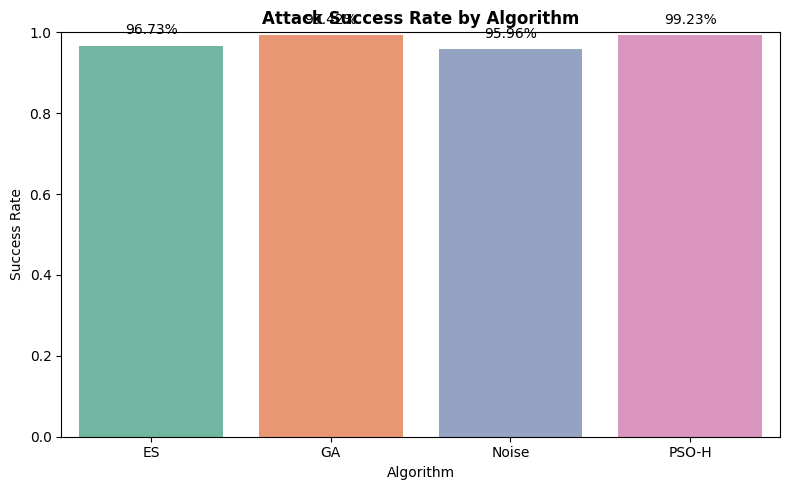

In [19]:
# CHART 1: Attack Success Rate comparison
plt.figure(figsize=(8, 5))
sns.barplot(x='algo', y='success', data=summary_df, palette='Set2')
plt.title('Attack Success Rate by Algorithm', fontsize=12, fontweight='bold')
plt.xlabel('Algorithm')
plt.ylabel('Success Rate')
plt.ylim(0, 1)
for i, row in summary_df.iterrows():
    plt.text(i, row['success'] + 0.02, f"{row['success']:.2%}", ha='center', va='bottom')
plt.tight_layout()
plt.show()


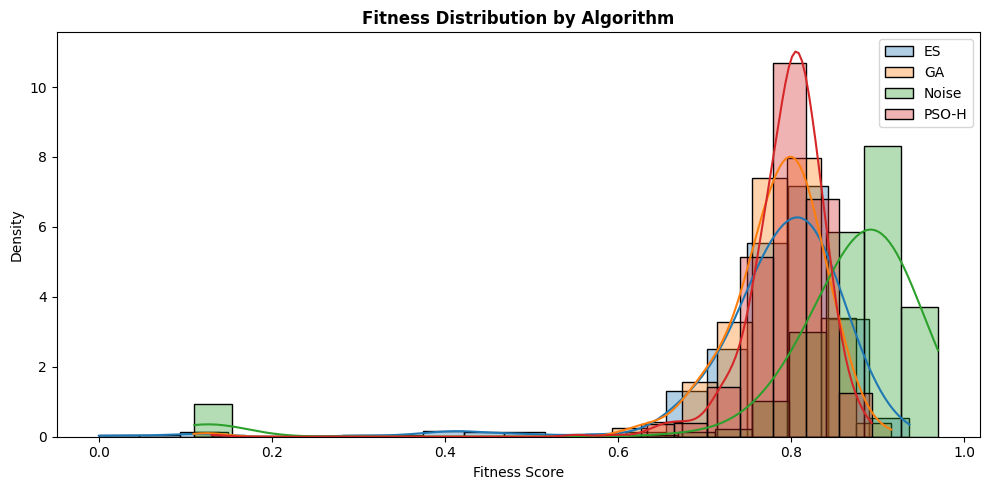

In [20]:
# CHART 2: Fitness Distribution for all algorithms
plt.figure(figsize=(10, 5))
for algo in loaded_algos:
    fitness_data = pd.to_numeric(ALGO_RUN_DIRS[algo]['fitness'], errors='coerce').dropna()
    if len(fitness_data) > 0:
        sns.histplot(fitness_data, label=algo, kde=True, stat='density', alpha=0.35, bins=20)

plt.legend()
plt.title('Fitness Distribution by Algorithm', fontsize=12, fontweight='bold')
plt.xlabel('Fitness Score')
plt.ylabel('Density')
plt.tight_layout()
plt.show()


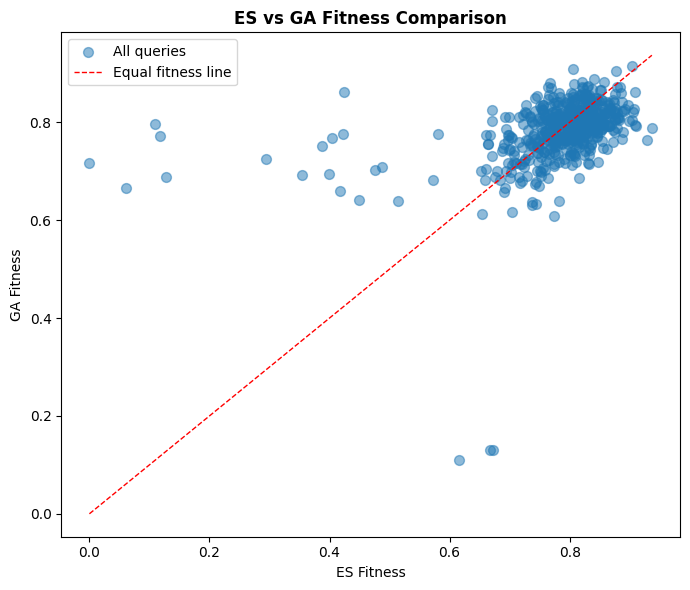

In [21]:
# CHART 3: Fitness comparison (first two algorithms as axes, others highlighted)
if len(loaded_algos) >= 2:
    algo1, algo2 = loaded_algos[0], loaded_algos[1]
    
    fit1 = pd.to_numeric(ALGO_RUN_DIRS[algo1]['fitness'], errors='coerce')
    fit2 = pd.to_numeric(ALGO_RUN_DIRS[algo2]['fitness'], errors='coerce')
    valid = fit1.notna() & fit2.notna()
    
    plt.figure(figsize=(7, 6))
    plt.scatter(fit1[valid], fit2[valid], alpha=0.5, s=50, label='All queries')
    
    # Add diagonal reference line
    if valid.any():
        min_val = min(fit1[valid].min(), fit2[valid].min())
        max_val = max(fit1[valid].max(), fit2[valid].max())
        plt.plot([min_val, max_val], [min_val, max_val], '--', color='red', linewidth=1, label='Equal fitness line')
    
    plt.xlabel(f'{algo1} Fitness')
    plt.ylabel(f'{algo2} Fitness')
    plt.title(f'{algo1} vs {algo2} Fitness Comparison', fontsize=12, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Need at least 2 algorithms for comparison scatter plot.')


In [22]:
# Load generation history files for all algorithms
all_generations = []

for algo in loaded_algos:
    algo_df = ALGO_RUN_DIRS[algo]
    algo_run_dir = ALGO_PATHS[algo]
    
    if algo_run_dir is None:
        continue
    
    # Convert to Path if string
    algo_run_path = Path(algo_run_dir) if isinstance(algo_run_dir, str) else algo_run_dir
    
    # Construct path to generation_history folder
    run_path = ROOT / algo_run_path.parent.parent  # Go up to run folder
    gen_history_dir = run_path / "generation_history"
    
    if not gen_history_dir.exists():
        print(f"[SKIP] No generation_history for {algo} at {gen_history_dir}")
        continue
    
    # Load all generation history CSV files
    history_files = list(gen_history_dir.glob("*.csv"))
    if not history_files:
        print(f"[SKIP] No history files for {algo}")
        continue
    
    print(f"[LOAD] {algo}: {len(history_files)} history files")
    
    for hf in history_files:
        try:
            h = pd.read_csv(hf)
            h["algo"] = algo
            all_generations.append(h)
        except Exception as e:
            print(f"  Warning: Could not load {hf.name}: {e}")

if all_generations:
    df_gen_combined = pd.concat(all_generations, ignore_index=True)
    print(f"\nTotal generation records: {len(df_gen_combined)}")
    print(f"Columns: {list(df_gen_combined.columns)}")
else:
    print("[ERROR] No generation history loaded!")
    df_gen_combined = pd.DataFrame()


[LOAD] ES: 520 history files
[LOAD] GA: 520 history files
[LOAD] Noise: 520 history files
[LOAD] PSO-H: 520 history files

Total generation records: 25830
Columns: ['query_id', 'algorithm', 'generation', 'best_fitness', 'avg_fitness', 'jailbroken_count', 'mutation_rate', 'best_suffix', 'suffix_word_count', 'alignment_score', 'readability_score', 'length_score', 'avg_eval_time', 'query_runtime_s', 'diversity', 'best_mutation_type', 'algo']


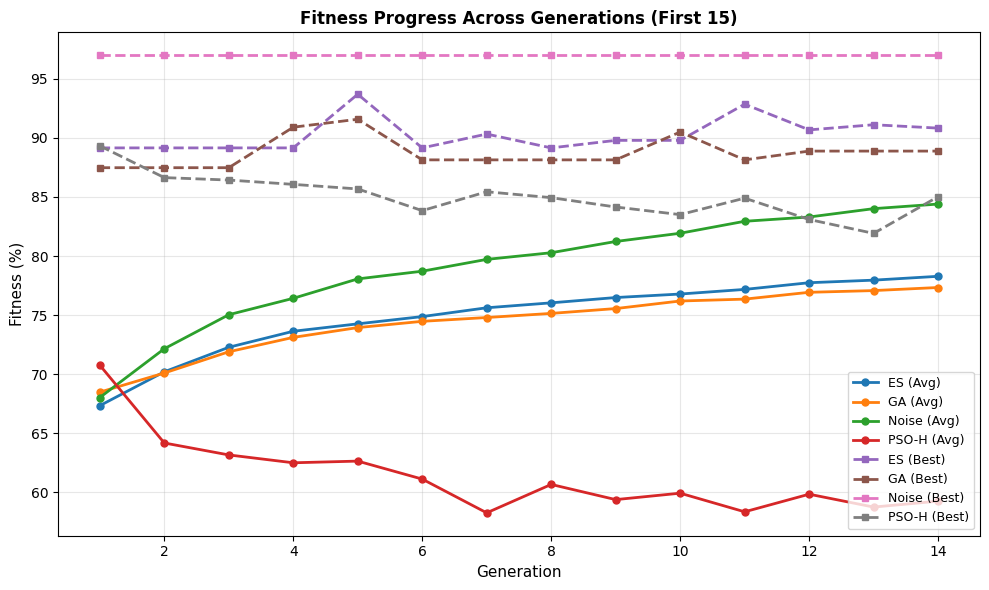

In [23]:
# CHART 4: Fitness Progress Across Generations (matching result_analysis pattern)
if not df_gen_combined.empty:
    # Normalize column names
    if "best_fitness" in df_gen_combined.columns and "fitness" not in df_gen_combined.columns:
        df_gen_combined["fitness"] = pd.to_numeric(df_gen_combined["best_fitness"], errors="coerce")
    
    # Ensure numeric conversion
    df_gen_combined["fitness"] = pd.to_numeric(df_gen_combined["fitness"], errors="coerce")
    df_gen_combined["generation"] = pd.to_numeric(df_gen_combined["generation"], errors="coerce")
    
    g = df_gen_combined.dropna(subset=["generation", "fitness"]).copy()
    
    if not g.empty:
        # Limit to first 15 generations for consistency
        g = g[g["generation"] <= 14].copy()
        
        # Group by algo and generation
        agg_fit = g.groupby(["algo", "generation"], as_index=False).agg(
            avg_fitness=("fitness", "mean"),
            best_fitness=("fitness", "max")
        )
        
        plt.figure(figsize=(10, 6))
        
        for algo in sorted(agg_fit["algo"].unique()):
            algo_data = agg_fit[agg_fit["algo"] == algo].sort_values("generation")
            plt.plot(algo_data["generation"], algo_data["avg_fitness"] * 100, 
                    marker="o", label=f"{algo} (Avg)", linewidth=2, markersize=5)
        
        for algo in sorted(agg_fit["algo"].unique()):
            algo_data = agg_fit[agg_fit["algo"] == algo].sort_values("generation")
            plt.plot(algo_data["generation"], algo_data["best_fitness"] * 100, 
                    marker="s", label=f"{algo} (Best)", linewidth=2, markersize=5, linestyle="--")
        
        plt.xlabel("Generation", fontsize=11)
        plt.ylabel("Fitness (%)", fontsize=11)
        plt.title("Fitness Progress Across Generations (First 15)", fontsize=12, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=9, loc='best')
        plt.tight_layout()
        plt.show()
    else:
        print("[INFO] No generation data after filtering")
else:
    print("[INFO] No generation history loaded")

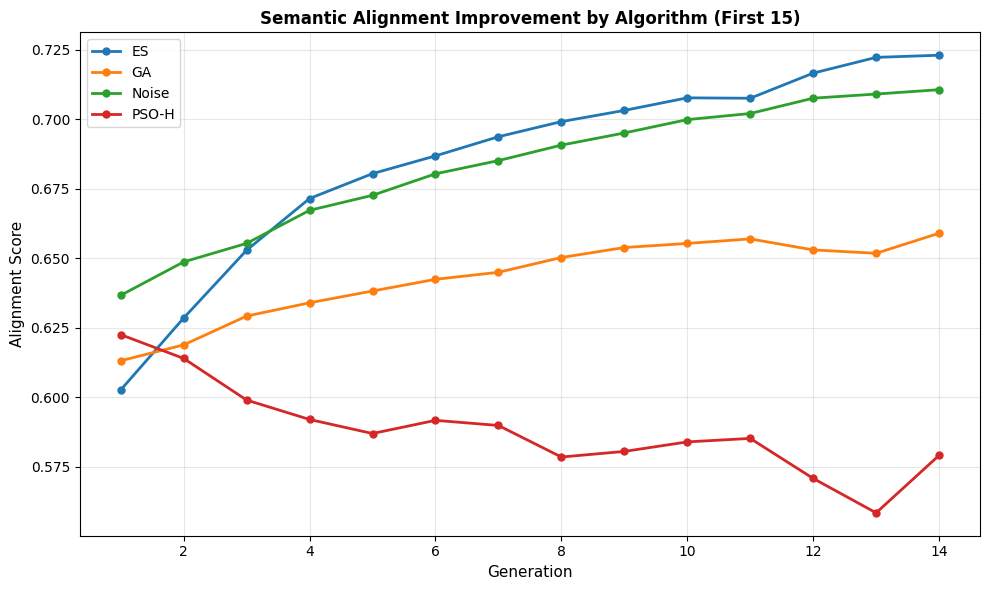

In [24]:
# CHART 5: Alignment Trend by Algorithm
if not df_gen_combined.empty and "alignment_score" in df_gen_combined.columns:
    g_align = df_gen_combined.dropna(subset=["generation", "alignment_score"]).copy()
    g_align = g_align[g_align["generation"] <= 14].copy()
    
    if not g_align.empty:
        g_align["generation"] = pd.to_numeric(g_align["generation"], errors="coerce")
        g_align["alignment_score"] = pd.to_numeric(g_align["alignment_score"], errors="coerce")
        
        agg_align = g_align.groupby(["algo", "generation"], as_index=False).agg(
            avg_alignment=("alignment_score", "mean"),
            best_alignment=("alignment_score", "max")
        )
        
        plt.figure(figsize=(10, 6))
        for algo in sorted(agg_align["algo"].unique()):
            algo_data = agg_align[agg_align["algo"] == algo].sort_values("generation")
            plt.plot(algo_data["generation"], algo_data["avg_alignment"], 
                    marker="o", label=algo, linewidth=2, markersize=5)
        
        plt.xlabel("Generation", fontsize=11)
        plt.ylabel("Alignment Score", fontsize=11)
        plt.title("Semantic Alignment Improvement by Algorithm (First 15)", fontsize=12, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=10, loc='best')
        plt.tight_layout()
        plt.show()
    else:
        print("[INFO] No alignment data available")
else:
    print("[INFO] No alignment_score column in generation data")


C:\Users\malay\AppData\Local\Temp\ipykernel_17232\2351077815.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(read_vals_by_algo, labels=labels_algo)


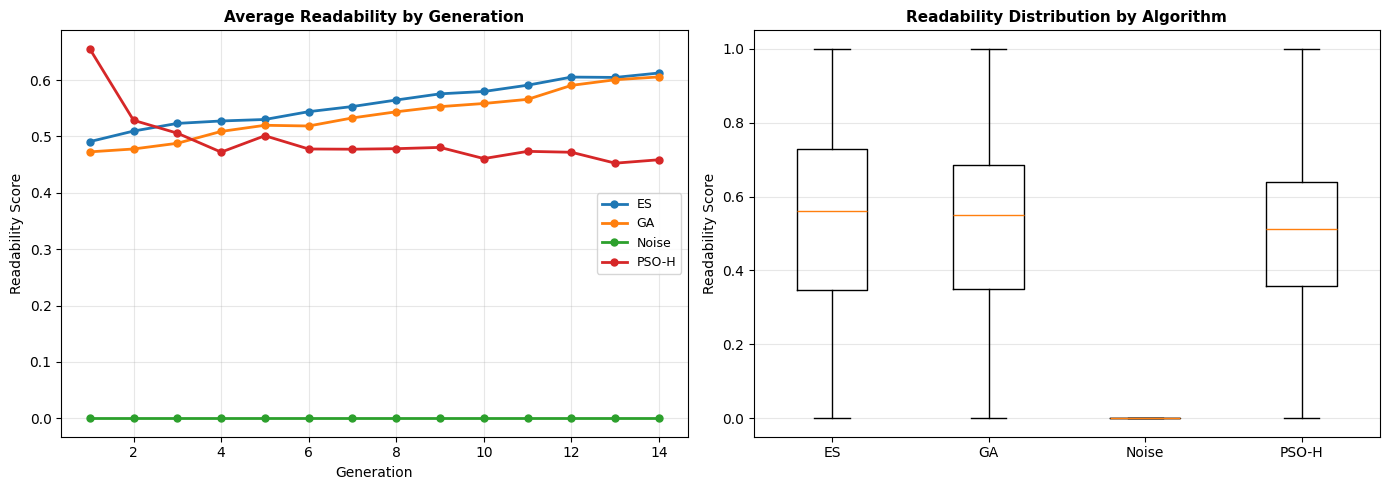

In [25]:
# CHART 6: Readability Analysis by Algorithm
if not df_gen_combined.empty and "readability_score" in df_gen_combined.columns:
    g_read = df_gen_combined.dropna(subset=["generation", "readability_score"]).copy()
    g_read = g_read[g_read["generation"] <= 14].copy()
    
    if not g_read.empty:
        g_read["generation"] = pd.to_numeric(g_read["generation"], errors="coerce")
        g_read["readability_score"] = pd.to_numeric(g_read["readability_score"], errors="coerce")
        
        agg_read = g_read.groupby(["algo", "generation"], as_index=False).agg(
            avg_readability=("readability_score", "mean")
        )
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Left: Progression by generation
        for algo in sorted(agg_read["algo"].unique()):
            algo_data = agg_read[agg_read["algo"] == algo].sort_values("generation")
            axes[0].plot(algo_data["generation"], algo_data["avg_readability"], 
                    marker="o", label=algo, linewidth=2, markersize=5)
        
        axes[0].set_title("Average Readability by Generation", fontsize=11, fontweight='bold')
        axes[0].set_xlabel("Generation")
        axes[0].set_ylabel("Readability Score")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(fontsize=9)
        
        # Right: Distribution across all samples
        read_vals_by_algo = []
        labels_algo = []
        for algo in sorted(df_gen_combined["algo"].unique()):
            rv = pd.to_numeric(
                df_gen_combined[df_gen_combined["algo"] == algo]["readability_score"], 
                errors="coerce"
            ).dropna()
            if len(rv) > 0:
                read_vals_by_algo.append(rv)
                labels_algo.append(algo)
        
        axes[1].boxplot(read_vals_by_algo, labels=labels_algo)
        axes[1].set_title("Readability Distribution by Algorithm", fontsize=11, fontweight='bold')
        axes[1].set_ylabel("Readability Score")
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
    else:
        print("[INFO] No readability data available")
else:
    print("[INFO] No readability_score column in generation data")


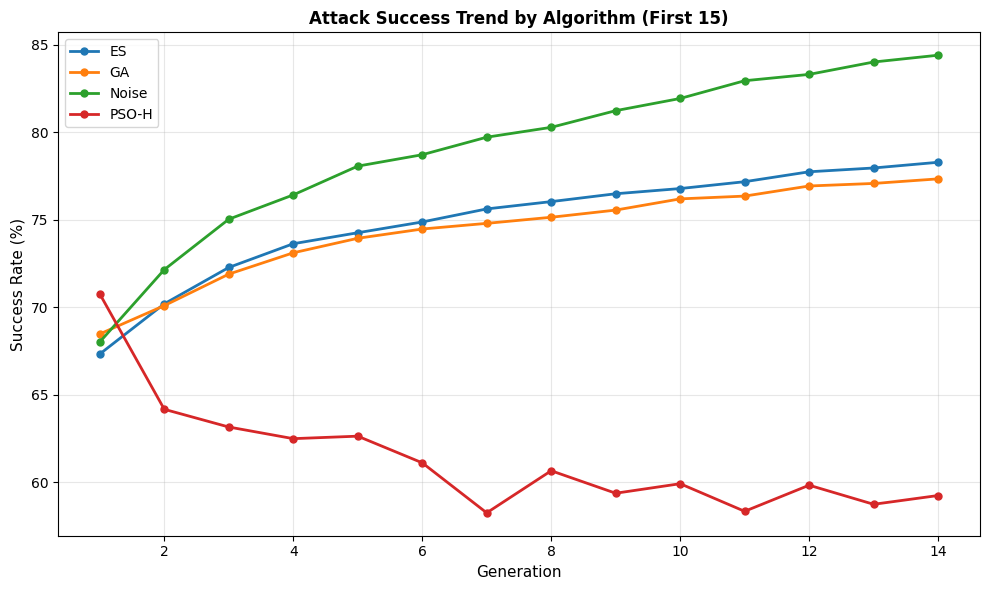

In [26]:
# CHART 7: Attack Success Trend by Algorithm (same calculation logic as result_analysis)
if not df_gen_combined.empty:
    g_jbk = df_gen_combined.dropna(subset=["generation"]).copy()
    g_jbk = g_jbk[g_jbk["generation"] <= 14].copy()

    if not g_jbk.empty:
        g_jbk["generation"] = pd.to_numeric(g_jbk["generation"], errors="coerce")

        # Match result_analysis logic: prefer fitness, fallback to jailbroken_count
        if "fitness" not in g_jbk.columns and "best_fitness" in g_jbk.columns:
            g_jbk["fitness"] = pd.to_numeric(g_jbk["best_fitness"], errors="coerce")

        if "fitness" in g_jbk.columns:
            g_jbk["fitness"] = pd.to_numeric(g_jbk["fitness"], errors="coerce")
            trend_asr = g_jbk.groupby(["algo", "generation"], as_index=False).agg(
                success_rate=("fitness", "mean")
            )
            trend_asr["success_rate"] = trend_asr["success_rate"] * 100
        elif "jailbroken_count" in g_jbk.columns:
            g_jbk["jailbroken_count"] = pd.to_numeric(g_jbk["jailbroken_count"], errors="coerce")
            trend_asr = g_jbk.groupby(["algo", "generation"], as_index=False).agg(
                success_rate=("jailbroken_count", "mean")
            )
            # Per-algorithm normalization for multi-algo comparison
            max_by_algo = trend_asr.groupby("algo")["success_rate"].transform("max")
            trend_asr["success_rate"] = np.where(
                max_by_algo > 0,
                (trend_asr["success_rate"] / max_by_algo) * 100,
                0.0,
            )
        else:
            trend_asr = pd.DataFrame({"algo": [], "generation": [], "success_rate": []})

        plt.figure(figsize=(10, 6))
        for algo in sorted(trend_asr["algo"].unique()):
            algo_data = trend_asr[trend_asr["algo"] == algo].sort_values("generation")
            plt.plot(algo_data["generation"], algo_data["success_rate"], marker="o", label=algo, linewidth=2, markersize=5)

        plt.xlabel("Generation", fontsize=11)
        plt.ylabel("Success Rate (%)", fontsize=11)
        plt.title("Attack Success Trend by Algorithm (First 15)", fontsize=12, fontweight="bold")
        plt.grid(True, alpha=0.3)
        plt.legend(fontsize=10, loc="best")
        plt.tight_layout()
        plt.show()
    else:
        print("[INFO] No generation data available")
else:
    print("[INFO] No generation data loaded")

## Key Comparisons & Interpretation

### Algorithm Performance Metrics
- **Success Rate**: Which algorithm achieves highest attack success?
- **Fitness Distribution**: How stable is each algorithm's fitness scores?
- **Alignment Score**: How well-aligned are adversarial examples?
- **Generation Efficiency**: How quickly does each algorithm converge?

### Questions to Answer
1. Which algorithm achieves the highest success rate?
2. Which algorithm converges fastest (if generation data available)?
3. How does Noise baseline compare to optimization algorithms?
4. Does PSO-LLM outperform PSO-Hybrid?
5. Is ES more stable than GA? Which algorithm is most robust?

### Customization Notes
- Edit the path variables at the top of the notebook to analyze different runs
- Set path to `None` to skip loading that algorithm
- All calculations automatically include/exclude algorithms based on what's loaded


C:\Users\malay\AppData\Local\Temp\ipykernel_17232\848093502.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='algo', y='alignment', data=summary_df, palette='Set2')


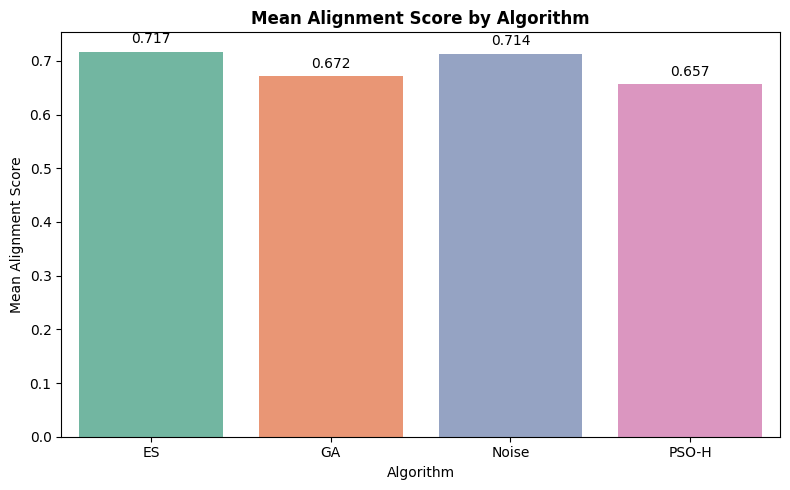

In [27]:
# CHART 5: Alignment Score comparison
alignment_available = all('alignment_score' in ALGO_RUN_DIRS[algo].columns for algo in loaded_algos)
if alignment_available:
    plt.figure(figsize=(8, 5))
    sns.barplot(x='algo', y='alignment', data=summary_df, palette='Set2')
    plt.title('Mean Alignment Score by Algorithm', fontsize=12, fontweight='bold')
    plt.xlabel('Algorithm')
    plt.ylabel('Mean Alignment Score')
    for i, row in summary_df.iterrows():
        plt.text(i, row['alignment'] + 0.01, f"{row['alignment']:.3f}", ha='center', va='bottom')
    plt.tight_layout()
    plt.show()


C:\Users\malay\AppData\Local\Temp\ipykernel_17232\4105956510.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=fitness_data, x='Algorithm', y='Fitness', palette='Set2')


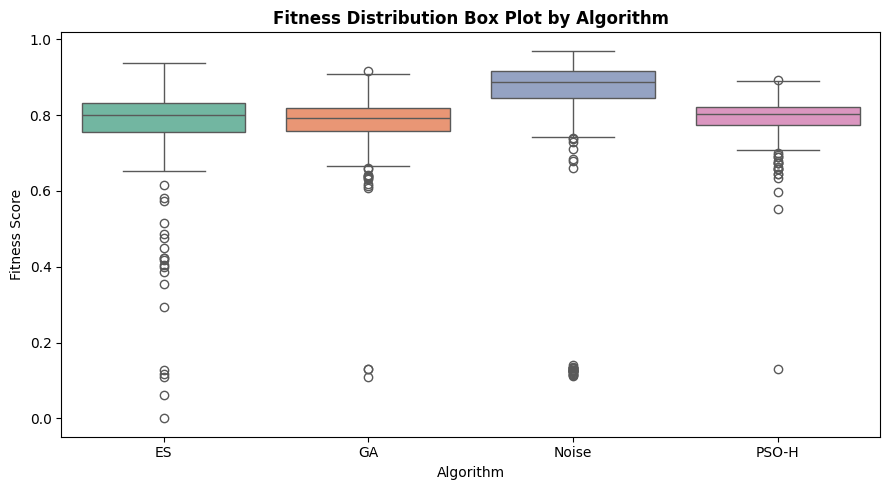

In [28]:
# CHART 6: Fitness Box Plot comparison across all algorithms
fitness_list = []
for algo in loaded_algos:
    fit_data = pd.to_numeric(ALGO_RUN_DIRS[algo]['fitness'], errors='coerce').dropna()
    if len(fit_data) > 0:
        fitness_list.append(pd.DataFrame({
            'Algorithm': algo,
            'Fitness': fit_data
        }))

if fitness_list:
    fitness_data = pd.concat(fitness_list, ignore_index=True)
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=fitness_data, x='Algorithm', y='Fitness', palette='Set2')
    plt.title('Fitness Distribution Box Plot by Algorithm', fontsize=12, fontweight='bold')
    plt.xlabel('Algorithm')
    plt.ylabel('Fitness Score')
    plt.tight_layout()
    plt.show()


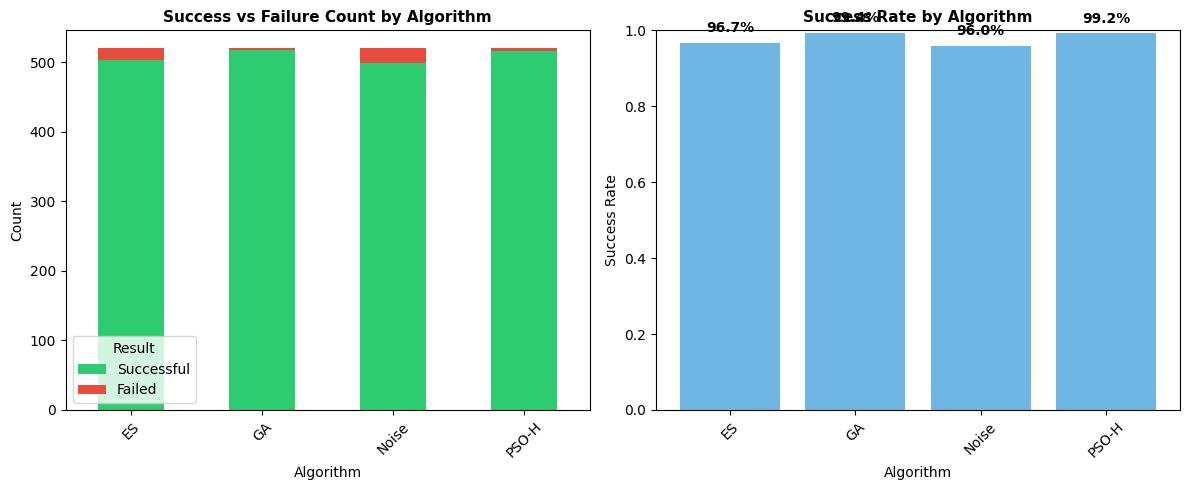

In [29]:
# CHART 7: Success Count and Rate detailed comparison
success_data = []
for algo in loaded_algos:
    df = ALGO_RUN_DIRS[algo]
    success_count = _parse_success(df['attack_success']).sum()
    total_count = len(df)
    success_rate = success_count / total_count if total_count > 0 else 0
    
    success_data.append({
        'Algorithm': algo,
        'Successful': success_count,
        'Failed': total_count - success_count
    })

success_df_counts = pd.DataFrame(success_data)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Stacked bar chart
success_df_counts.set_index('Algorithm')[['Successful', 'Failed']].plot(
    kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Success vs Failure Count by Algorithm', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Algorithm')
axes[0].legend(title='Result')
axes[0].tick_params(axis='x', rotation=45)

# Success rate with annotations
success_summary = summary_df[['algo', 'success']].copy()
axes[1].bar(success_summary['algo'], success_summary['success'], color='#3498db', alpha=0.7)
for i, (algo, rate) in enumerate(zip(success_summary['algo'], success_summary['success'])):
    axes[1].text(i, rate + 0.02, f'{rate:.1%}', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Success Rate by Algorithm', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Success Rate')
axes[1].set_xlabel('Algorithm')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
